# 🌊 Week 2 Lab — Foundations of Data Stream Mining

**Data Stream Mining — NOVA IMS**  
**LU1 — Foundations of Data Stream Mining**  
**Laboratory duration: 1h15**

---

## Big Question

> **What changes when data never stops arriving?**

In the lecture, we saw that streaming is **computation under constraints**:

- observations arrive sequentially;
- the stream may be potentially unbounded;
- we often have only one pass;
- memory is bounded;
- processing time is bounded;
- useful information must be preserved as **state**.

In this lab, we will turn those ideas into executable Python.

### Learning objectives

By the end of the lab, you should be able to:

1. represent a stream as a Python iterator/generator;
2. process observations one at a time;
3. distinguish batch processing from incremental processing;
4. distinguish **stateless** and **stateful** stream operators;
5. compute count, sum, mean, and variance incrementally;
6. explain why online statistics do not require storing the entire stream;
7. connect a hand-built incremental calculation to a streaming library such as **River**.

> **Key idea for today:** The stream disappears. The state remains.

# 0. Setup — 5 min

We will use only standard Python plus NumPy, Pandas, and Matplotlib for the core activity.

River is used only in the final section. If River is not installed, the notebook will still run; you can install it with:

```python
%pip install -q river
```

In [1]:
import math
from datetime import datetime, timedelta
from itertools import islice

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 2.5.3
Pandas: 3.0.5


## Our running example: a smart-building electricity stream

Imagine a sensor that emits one electricity-demand observation every minute.

Each observation is an **event**. We do not begin with a completed CSV file; instead, observations are produced as they are needed.

We will simulate the sensor locally so that the activity is reproducible and does not depend on an internet connection.

In [2]:
def smart_building_stream(n=None, seed=42):
    """Yield one simulated electricity observation at a time.

    Parameters
    ----------
    n : int or None
        Number of observations to emit. If None, the stream is unbounded.
    seed : int
        Random seed for reproducibility.
    """
    local_rng = np.random.default_rng(seed)
    start = datetime(2026, 9, 14, 9, 0)
    i = 0

    while n is None or i < n:
        # A smooth short-term pattern + random measurement noise.
        demand_kw = 450 + 30 * math.sin(i / 8) + local_rng.normal(0, 8)
        temperature_c = 21 + 1.2 * math.sin(i / 15) + local_rng.normal(0, 0.3)

        yield {
            "timestamp": start + timedelta(minutes=i),
            "demand_kw": float(demand_kw),
            "temperature_c": float(temperature_c),
        }
        i += 1

# 1. Creating and Consuming a Stream — 10 min

A Python **generator** is a useful mental model for a data stream: it produces one observation at a time.

The generator itself does **not** contain all future observations in memory.

In [3]:
stream = smart_building_stream(n=5)

print(stream)
print("First observation:", next(stream))
print("Second observation:", next(stream))

<generator object smart_building_stream at 0x000002857035F880>
First observation: {'timestamp': datetime.datetime(2026, 9, 14, 9, 0), 'demand_kw': 452.43773663803546, 'temperature_c': 20.68800476812785}
Second observation: {'timestamp': datetime.datetime(2026, 9, 14, 9, 1), 'demand_kw': 459.7438515680085, 'temperature_c': 21.36211016882544}


Notice what happened:

- `next(stream)` returned one event;
- the stream advanced;
- asking again returned the next event;
- we did not index the stream using `stream[0]` or `stream[1]`.

This is **sequential access**.

In [4]:
for event in smart_building_stream(n=5):
    print(
        event["timestamp"].strftime("%H:%M"),
        "->",
        f'{event["demand_kw"]:.1f} kW'
    )

09:00 -> 452.4 kW
09:01 -> 459.7 kW
09:02 -> 441.8 kW
09:03 -> 462.0 kW
09:04 -> 464.2 kW


## Potentially unbounded streams

A stream does not need to have a known final observation.

The function below can produce data indefinitely because `n=None`.

**Important:** never execute `list(smart_building_stream(n=None))`. There is no natural end to collect.

In [5]:
endless_stream = smart_building_stream(n=None)

# Consume only the first 5 observations from a potentially unbounded stream.
first_five = list(islice(endless_stream, 5))

for event in first_five:
    print(event["timestamp"], round(event["demand_kw"], 2))

2026-09-14 09:00:00 452.44
2026-09-14 09:01:00 459.74
2026-09-14 09:02:00 441.81
2026-09-14 09:03:00 462.01
2026-09-14 09:04:00 464.25


### ✍️ Quick check

Answer before running anything else:

1. Why can we safely call `next()` on an unbounded generator?
2. Why is converting an unbounded generator to a list a problem?
3. Which operation better resembles a real stream processor: indexing arbitrary rows or repeatedly consuming the next observation?

# 2. Batch vs Incremental Processing — 10 min

Suppose we want the average electricity demand.

In a **batch** workflow, a natural approach is:

1. collect all values;
2. store them;
3. calculate the statistic.

In [6]:
# Batch approach: first materialize the entire stream segment.
batch_values = [event["demand_kw"] for event in smart_building_stream(n=60)]

batch_mean = np.mean(batch_values)

print("Observations stored:", len(batch_values))
print("Batch mean:", round(batch_mean, 3), "kW")

Observations stored: 60
Batch mean: 452.117 kW


That works for 60 observations. But imagine the sensor runs for years, with thousands or millions of sensors.

The streaming question is different:

> **Can we compute the same result while each observation passes only once?**

For a mean, we only need two pieces of state:

- how many observations we have seen: \(n\);
- their accumulated sum: \(S\).

Then:

$
\mu = \frac{S}{n}
$

In [7]:
count = 0
running_sum = 0.0

for event in smart_building_stream(n=60):
    x = event["demand_kw"]
    count += 1
    running_sum += x

streaming_mean = running_sum / count

print("Raw observations retained by the algorithm: 0")
print("State variables: count and running_sum")
print("Streaming mean:", round(streaming_mean, 3), "kW")
print("Same as batch?", np.isclose(streaming_mean, batch_mean))

Raw observations retained by the algorithm: 0
State variables: count and running_sum
Streaming mean: 452.117 kW
Same as batch? True


### What changed?

The mathematical answer did not change. The **computational strategy** did.

| Batch | Incremental |
|---|---|
| Store observations | Process and discard observations |
| Compute after collection | Update while data arrives |
| Memory grows with data | State can remain constant-size |
| Dataset has a boundary | Can run continuously |

For this example, the incremental algorithm uses constant-size state with respect to the number of observations: **O(1) memory**.

# 3. Stateless vs Stateful Operators — 10 min

A useful way to think about stream processing is through **operators**.

## Stateless operator

A stateless operator can process the current observation without remembering previous observations:

$
x_t \rightarrow f(x_t)
$

Examples: unit conversion, extracting a field, applying a fixed threshold.

## Stateful operator

A stateful operator combines the current observation with information preserved from the past:

$
(state_{t-1}, x_t) \rightarrow state_t
$

Examples: count, mean, variance, windows, and machine-learning models.

In [8]:
# STATELESS OPERATOR: convert kW to MW.
def kw_to_mw(event):
    return {
        **event,
        "demand_mw": event["demand_kw"] / 1000,
    }

for event in islice(smart_building_stream(n=None), 3):
    transformed = kw_to_mw(event)
    print(round(transformed["demand_mw"], 4), "MW")

0.4524 MW
0.4597 MW
0.4418 MW


In [9]:
# STATELESS OPERATOR: keep only observations above a fixed threshold.
def high_demand_only(events, threshold_kw=470):
    for event in events:
        if event["demand_kw"] > threshold_kw:
            yield event

for event in high_demand_only(smart_building_stream(n=30), threshold_kw=470):
    print(event["timestamp"].strftime("%H:%M"), round(event["demand_kw"], 1))

09:05 474.6
09:06 471.0
09:07 476.8
09:08 478.2
09:09 484.1
09:10 477.0
09:11 489.2
09:12 476.5
09:13 484.2
09:14 482.8
09:15 495.8
09:16 473.2
09:17 480.4
09:18 472.4
09:20 473.9


### ✍️ Exercise 1 — Create a stateless operator

Create a function `add_is_warm(event)` that adds a Boolean field called `is_warm`.

Use a fixed threshold of **22 °C**.

Ask yourself: **does this operator need to remember previous events?**

In [ ]:
# TODO — Exercise 1
# Write your solution here.

# def add_is_warm(event):
#     ...

<details>
<summary><b>✅ Suggested solution — open after trying</b></summary>

```python
def add_is_warm(event):
    return {
        **event,
        "is_warm": event["temperature_c"] > 22,
    }
```

No previous observation is needed, so this is **stateless**.
</details>

# 4. Count, Sum, and Running Mean — 15 min

Now we move to **stateful** computation.

The simplest persistent state is a counter:

$
n_t = n_{t-1} + 1
$

The raw observation can disappear after the update; the count remains.

In [10]:
count = 0

for event in smart_building_stream(n=10):
    count += 1
    print(event["timestamp"].strftime("%H:%M"), "-> count =", count)

09:00 -> count = 1
09:01 -> count = 2
09:02 -> count = 3
09:03 -> count = 4
09:04 -> count = 5
09:05 -> count = 6
09:06 -> count = 7
09:07 -> count = 8
09:08 -> count = 9
09:09 -> count = 10


## A running mean as a direct state update

We can update the mean without explicitly storing the running sum:

$
\mu_n = \mu_{n-1} + \frac{x_n - \mu_{n-1}}{n}
$

The state is only:

$
(n, \mu)
$

Do not focus on memorizing the formula. Focus on the pattern:

> **old state + new observation → new state**

In [11]:
count = 0
mean = 0.0
history = []  # only for visualization in this teaching cell, not required by the algorithm

for event in smart_building_stream(n=20):
    x = event["demand_kw"]
    count += 1
    mean = mean + (x - mean) / count
    history.append(mean)

print("Final running mean:", round(mean, 3), "kW")
print("State needed by the algorithm: count + mean")

Final running mean: 473.031 kW
State needed by the algorithm: count + mean


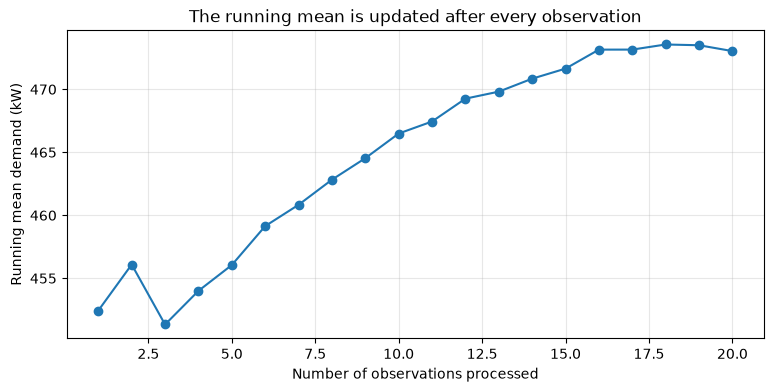

In [12]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(history) + 1), history, marker="o")
plt.xlabel("Number of observations processed")
plt.ylabel("Running mean demand (kW)")
plt.title("The running mean is updated after every observation")
plt.grid(alpha=0.3)
plt.show()

### ✍️ Exercise 2 — Inspect the state

Process **100 observations** and print the running mean after observations:

`1, 5, 10, 25, 50, 100`

Questions:

1. Does the state grow from 2 variables to 100 variables?
2. Does the running mean become available only at the end?
3. What is the advantage of having a valid statistic after every event?

In [ ]:
# TODO — Exercise 2
# Hint: use a set of checkpoints such as {1, 5, 10, 25, 50, 100}.

<details>
<summary><b>✅ Suggested solution — open after trying</b></summary>

```python
checkpoints = {1, 5, 10, 25, 50, 100}
count = 0
mean = 0.0

for event in smart_building_stream(n=100):
    x = event["demand_kw"]
    count += 1
    mean += (x - mean) / count

    if count in checkpoints:
        print(f"n={count:3d} -> mean={mean:.2f} kW")
```


</details>

# 5. Variance Without Storing the Data — 15 min

A mean is useful, but it does not tell us how variable the stream is.

A natural question is:

> **Can we update variance online without storing every past observation?**

Yes. A classic solution is **Welford's online algorithm**.

We keep only three pieces of state:

$
n, \quad \mu, \quad M_2
$

For each new value \(x\):

$
\begin{aligned}
n &\leftarrow n + 1 \\
\delta &\leftarrow x - \mu \\
\mu &\leftarrow \mu + \frac{\delta}{n} \\
M_2 &\leftarrow M_2 + \delta(x - \mu)
\end{aligned}
$

For \(n>1\), the sample variance is:

$
s^2 = \frac{M_2}{n-1}
$

**You do not need to memorize these equations today.** The important idea is that variance can also be represented by a small persistent state.

In [13]:
class RunningStats:
    """Online count, mean, and sample variance using Welford's method."""

    def __init__(self):
        self.n = 0
        self.mean = 0.0
        self.M2 = 0.0

    def update(self, x):
        self.n += 1

        delta = x - self.mean
        self.mean += delta / self.n
        delta2 = x - self.mean
        self.M2 += delta * delta2

    @property
    def variance(self):
        if self.n < 2:
            return float("nan")
        return self.M2 / (self.n - 1)

    @property
    def std(self):
        return math.sqrt(self.variance) if self.n >= 2 else float("nan")

In [14]:
stats = RunningStats()

for event in smart_building_stream(n=100):
    stats.update(event["demand_kw"])

print("Count:", stats.n)
print("Online mean:", round(stats.mean, 4))
print("Online variance:", round(stats.variance, 4))
print("Online standard deviation:", round(stats.std, 4))

Count: 100
Online mean: 449.8973
Online variance: 553.8592
Online standard deviation: 23.5342


## Validate against batch NumPy

A very important scientific habit is to test an incremental implementation against a trusted batch calculation on a finite sample.

Because Welford above computes the **sample variance**, we use `ddof=1` in NumPy.

In [15]:
values = np.array([
    event["demand_kw"]
    for event in smart_building_stream(n=100)
])

print("Mean equal?", np.isclose(stats.mean, np.mean(values)))
print("Variance equal?", np.isclose(stats.variance, np.var(values, ddof=1)))
print()
print("NumPy mean:", np.mean(values))
print("Online mean:", stats.mean)
print("NumPy sample variance:", np.var(values, ddof=1))
print("Online sample variance:", stats.variance)

Mean equal? True
Variance equal? True

NumPy mean: 449.89725590959347
Online mean: 449.8972559095935
NumPy sample variance: 553.8591513342877
Online sample variance: 553.8591513342894


## Monitor statistics as the stream arrives

The algorithm itself does not need history. For teaching purposes, however, we can record snapshots of its **state** so that we can visualize how the estimates evolve.

In [16]:
stats = RunningStats()
state_log = []

for event in smart_building_stream(n=120):
    stats.update(event["demand_kw"])
    state_log.append({
        "n": stats.n,
        "mean": stats.mean,
        "variance": stats.variance,
    })

state_df = pd.DataFrame(state_log)
state_df.head()

,n,mean,variance
0,1,452.437737,NaN
1,2,456.090794,26.689658
2,3,451.331808,81.288661
3,4,454.001581,82.703185
4,5,456.050936,83.026671


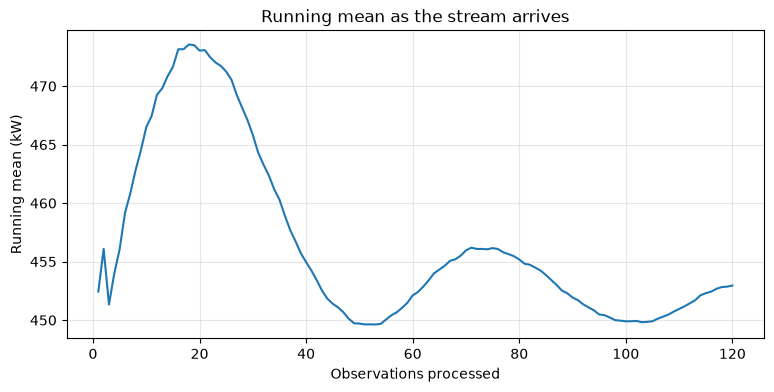

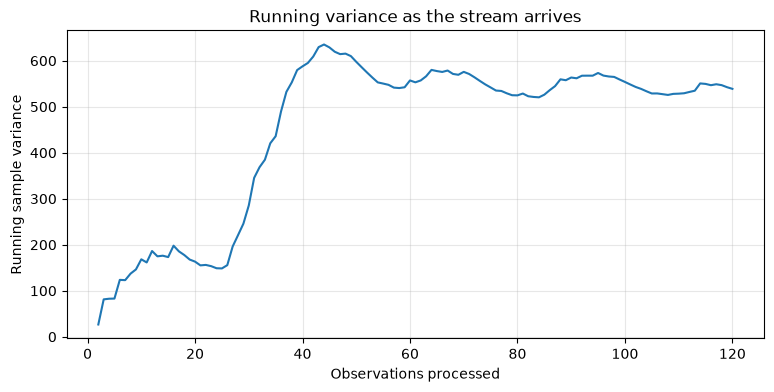

In [17]:
plt.figure(figsize=(9, 4))
plt.plot(state_df["n"], state_df["mean"])
plt.xlabel("Observations processed")
plt.ylabel("Running mean (kW)")
plt.title("Running mean as the stream arrives")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(state_df["n"], state_df["variance"])
plt.xlabel("Observations processed")
plt.ylabel("Running sample variance")
plt.title("Running variance as the stream arrives")
plt.grid(alpha=0.3)
plt.show()

### ✍️ Exercise 3 — Explain Welford in words

Without looking at the equations, complete the following sentence:

> To maintain the variance of an arbitrarily long stream, Welford's algorithm stores ____________________________________________.

Then answer:

- How many raw observations does `RunningStats` keep?
- Does its state become larger after processing 1,000,000 observations?
- Why is this compatible with bounded-memory stream processing?

# 6. The Same Idea with River — 7 min

Until now we deliberately implemented the statistics ourselves so that the streaming mechanism is visible.

A streaming library packages the same idea into reusable objects.

River provides incremental statistics through `river.stats`.

> **Pedagogical rule:** first understand the update loop; then use the framework.

In [18]:
try:
    from river import stats as river_stats
    RIVER_AVAILABLE = True
    print("River is available.")
except ImportError:
    RIVER_AVAILABLE = False
    print("River is not installed in this environment.")
    print("If needed, run: %pip install -q river")

River is available.


In [19]:
if RIVER_AVAILABLE:
    river_mean = river_stats.Mean()
    river_var = river_stats.Var(ddof=1)

    for event in smart_building_stream(n=100):
        x = event["demand_kw"]
        river_mean.update(x)
        river_var.update(x)

    print("River mean:", river_mean.get())
    print("River variance:", river_var.get())

    # Compare with our own Welford implementation.
    ours = RunningStats()
    for event in smart_building_stream(n=100):
        ours.update(event["demand_kw"])

    print("Mean agrees?", np.isclose(river_mean.get(), ours.mean))
    print("Variance agrees?", np.isclose(river_var.get(), ours.variance))
else:
    print("Skipping River comparison. The core lab remains complete.")

River mean: 449.8972559095935
River variance: 553.8591513342894
Mean agrees? True
Variance agrees? True


## Why this matters for Machine Learning

The update pattern is no longer just about statistics:

\[
state_t = update(state_{t-1}, x_t)
\]

The **state** could represent:

- a counter;
- a mean;
- a variance;
- a frequency estimate;
- a cluster summary;
- a decision tree;
- an online predictive model.

A machine-learning model is also a form of persistent state.

This is the bridge from **streaming statistics** to **incremental learning**.

# 7. Final Reflection — 3 min

## Five things to leave with

1. A stream can be represented as an iterator that emits observations sequentially.
2. Batch processing often stores first and computes later.
3. Streaming algorithms update results **while observations arrive**.
4. Count, mean, and variance can be maintained using compact state.
5. Incremental Machine Learning extends the same state-update principle to models.

---

## Bridge to Week 3

Our running mean and variance summarize **all observations since the beginning**.

Now imagine that the building suddenly changes its operating regime after 100,000 observations.

> **Should observations from months ago have the same importance as observations from the last ten minutes?**

That question leads directly to next week's topic:

### **How can we represent data that we cannot store forever?**

We will study **windows, summarization, sampling, noise handling, and memory–accuracy trade-offs**.

# ⭐ Optional Extension — If You Finish Early

Create a reusable stateful class called `RunningMinMax` that stores only:

- the number of observations seen;
- the current minimum;
- the current maximum.

It should expose an `update(x)` method.

Then process 1,000 electricity-demand observations and verify your final minimum and maximum against NumPy.

**Question:** does the memory used by your algorithm depend on whether you process 10, 1,000, or 1,000,000 observations?

In [ ]:
# TODO — Optional extension

# class RunningMinMax:
#     def __init__(self):
#         ...
#
#     def update(self, x):
#         ...

# References

- Babcock, B., Babu, S., Datar, M., Motwani, R., & Widom, J. (2002). *Models and Issues in Data Stream Systems*. PODS.
- Domingos, P., & Hulten, G. (2000). *Mining High-Speed Data Streams*. KDD.
- Gama, J. (2012). *A Survey on Learning from Data Streams: Current and Future Trends*. Progress in Artificial Intelligence, 1, 45–55.
- Muthukrishnan, S. (2005). *Data Streams: Algorithms and Applications*.
- Welford, B. P. (1962). *Note on a Method for Calculating Corrected Sums of Squares and Products*. Technometrics, 4(3), 419–420.

---

### Lab takeaway

> **The stream disappears. The state remains.**